# Regridded Slope Modeling: Linear Regression vs Decision Tree

This notebook runs both analyses on the 5x5 regridded dataset in `output/station_data_grid_5x5.csv` and compares their predictive performance on the same feature set.

## Workflow
- Load the regridded grid-cell table
- Keep a shared feature set for both models
- Use `station_count` as a sample weight so cells with more underlying stations count more
- Fit a multilinear regression and a tuned decision tree on the same train/test split
- Save metrics, predictions, and comparison plots under `notebook_outputs/regridded_model_comparison/`

Rows with missing shared features are dropped before modeling.

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeRegressor

sns.set_style('darkgrid')
%matplotlib inline

DATA_PATH = Path('../output/station_data_grid_5x5.csv')
OUTPUT_DIR = Path('./notebook_outputs/regridded_model_comparison')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'slope'
FEATURE_COLS = ['climo_temp', 'climo_humidity', 'Abs_Latitude', 'Longitude', 'Elevation', 'station_count']
ID_COLS = ['cell_id', 'lat_bin', 'lon_bin', 'lat_min', 'lat_max', 'lon_min', 'lon_max']
RANDOM_STATE = 42
TEST_SIZE = 0.2

print(f'Data path: {DATA_PATH.resolve()}')
print(f'Output directory: {OUTPUT_DIR.resolve()}')
print(f'Shared features: {FEATURE_COLS}')

Data path: /net/fs06/d3/gretar/bc3_urop/output/station_data_grid_5x5.csv
Output directory: /net/fs06/d3/gretar/bc3_urop/output/regridded_model_comparison
Shared features: ['climo_temp', 'climo_humidity', 'Latitude', 'Longitude', 'Elevation', 'station_count']


In [ ]:
df = pd.read_csv(DATA_PATH)
df['Abs_Latitude'] = df['Latitude'].abs()
print(f'Loaded {len(df)} grid cells with {len(df.columns)} columns')

required_cols = FEATURE_COLS + [TARGET_COL] + ID_COLS
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

missing_summary = df[FEATURE_COLS + [TARGET_COL]].isna().sum().sort_values(ascending=False)
print('Missing values in modeling columns:')
print(missing_summary.to_string())

model_df = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
model_df['sample_weight'] = model_df['station_count'].clip(lower=1)

dropped_rows = len(df) - len(model_df)
print(f'Rows retained for modeling: {len(model_df)}')
print(f'Rows dropped due to missing shared features: {dropped_rows}')
print('Station count summary for retained rows:')
print(model_df['station_count'].describe().to_string())

model_df.head()

Loaded 673 grid cells with 19 columns
Missing values in modeling columns:
climo_humidity    75
slope              0
station_count      0
Elevation          0
Longitude          0
Latitude           0
climo_temp         0
Rows retained for modeling: 598
Rows dropped due to missing shared features: 75
Station count summary for retained rows:
count    598.000000
mean      10.198997
std       20.307820
min        1.000000
25%        1.000000
50%        3.000000
75%        9.000000
max      147.000000


,cell_id,lat_bin,lon_bin,lat_min,lat_max,lon_min,lon_max,station_count,Latitude,Longitude,Elevation,slope,intercept,r_squared,climo_temp,climo_humidity,slope_min,slope_max,slope_std,sample_weight
11,-55_-75,-55,-75,-55,-50,-75,-70,1,-53.000,-70.9670,37.0,-0.162984,0.032669,0.019591,6.736994,75.225000,-0.162984,-0.162984,0.000000,1
12,-55_-70,-55,-70,-55,-50,-70,-65,2,-53.230,-68.7895,20.3,0.317727,-0.076685,0.062892,6.989042,72.170833,0.191738,0.443715,0.125988,2
16,-50_-70,-50,-70,-50,-45,-70,-65,1,-45.783,-67.5000,58.0,0.445777,-0.097190,0.126044,13.159973,49.891667,0.445777,0.445777,0.000000,1
19,-50_165,-50,165,-50,-45,165,170,1,-46.417,168.3330,2.0,1.044168,-0.192902,0.434210,10.020309,83.183333,1.044168,1.044168,0.000000,1
20,-50_170,-50,170,-50,-45,170,175,1,-45.900,170.5200,2.0,0.661559,0.020676,0.049897,10.838073,78.000000,0.661559,0.661559,0.000000,1


In [4]:
split_data = train_test_split(
    model_df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
train_idx, test_idx = split_data

train_df = model_df.loc[train_idx].copy()
test_df = model_df.loc[test_idx].copy()

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]
w_train = train_df['sample_weight']
w_test = test_df['sample_weight']

print(f'Train rows: {len(train_df)}')
print(f'Test rows: {len(test_df)}')
print(f'Train weight sum: {w_train.sum():.0f}')
print(f'Test weight sum: {w_test.sum():.0f}')

def regression_metrics(y_true, y_pred, sample_weight):
    return {
        'R2': r2_score(y_true, y_pred, sample_weight=sample_weight),
        'RMSE': mean_squared_error(y_true, y_pred, sample_weight=sample_weight, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred, sample_weight=sample_weight),
    }

Train rows: 478
Test rows: 120
Train weight sum: 5145
Test weight sum: 954


In [5]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train, sample_weight=w_train)

linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

linear_metrics = {
    'model': 'Weighted Linear Regression',
    'train_rows': len(train_df),
    'test_rows': len(test_df),
    'train_weight_sum': float(w_train.sum()),
    'test_weight_sum': float(w_test.sum()),
}
linear_metrics.update({f'train_{k.lower()}': v for k, v in regression_metrics(y_train, linear_train_pred, w_train).items()})
linear_metrics.update({f'test_{k.lower()}': v for k, v in regression_metrics(y_test, linear_test_pred, w_test).items()})

linear_coefficients = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': linear_model.coef_,
}).sort_values('coefficient', key=np.abs, ascending=False)

print('Linear regression metrics:')
print(pd.Series(linear_metrics).to_string())
print('')
print('Linear regression coefficients:')
print(linear_coefficients.to_string(index=False))

Linear regression metrics:
model               Weighted Linear Regression
train_rows                                 478
test_rows                                  120
train_weight_sum                          5145
test_weight_sum                            954
train_r2                              0.520599
train_rmse                            0.337646
train_mae                             0.255266
test_r2                               0.428372
test_rmse                              0.36413
test_mae                              0.264873

Linear regression coefficients:
        feature  coefficient
     climo_temp    -0.025270
       Latitude     0.007593
 climo_humidity    -0.006700
  station_count    -0.003137
      Longitude     0.001759
      Elevation    -0.000065


In [6]:
param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
}

tree_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
tree_search.fit(X_train, y_train, sample_weight=w_train)

tree_model = tree_search.best_estimator_
tree_train_pred = tree_model.predict(X_train)
tree_test_pred = tree_model.predict(X_test)

tree_metrics = {
    'model': 'Decision Tree Regressor',
    'best_params': str(tree_search.best_params_),
    'best_cv_r2': float(tree_search.best_score_),
    'train_rows': len(train_df),
    'test_rows': len(test_df),
    'train_weight_sum': float(w_train.sum()),
    'test_weight_sum': float(w_test.sum()),
}
tree_metrics.update({f'train_{k.lower()}': v for k, v in regression_metrics(y_train, tree_train_pred, w_train).items()})
tree_metrics.update({f'test_{k.lower()}': v for k, v in regression_metrics(y_test, tree_test_pred, w_test).items()})

tree_importances = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': tree_model.feature_importances_,
}).sort_values('importance', ascending=False)

print('Best decision tree parameters:')
print(tree_search.best_params_)
print('')
print('Decision tree metrics:')
print(pd.Series(tree_metrics).to_string())
print('')
print('Decision tree feature importances:')
print(tree_importances.to_string(index=False))

Best decision tree parameters:
{'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}

Decision tree metrics:
model                                         Decision Tree Regressor
best_params         {'max_depth': 5, 'min_samples_leaf': 10, 'min_...
best_cv_r2                                                   0.408837
train_rows                                                        478
test_rows                                                         120
train_weight_sum                                                 5145
test_weight_sum                                                   954
train_r2                                                     0.797031
train_rmse                                                   0.219698
train_mae                                                    0.149214
test_r2                                                      0.480066
test_rmse                                                    0.347275
test_mae                                

Decision tree depth: 5
Decision tree leaves: 20


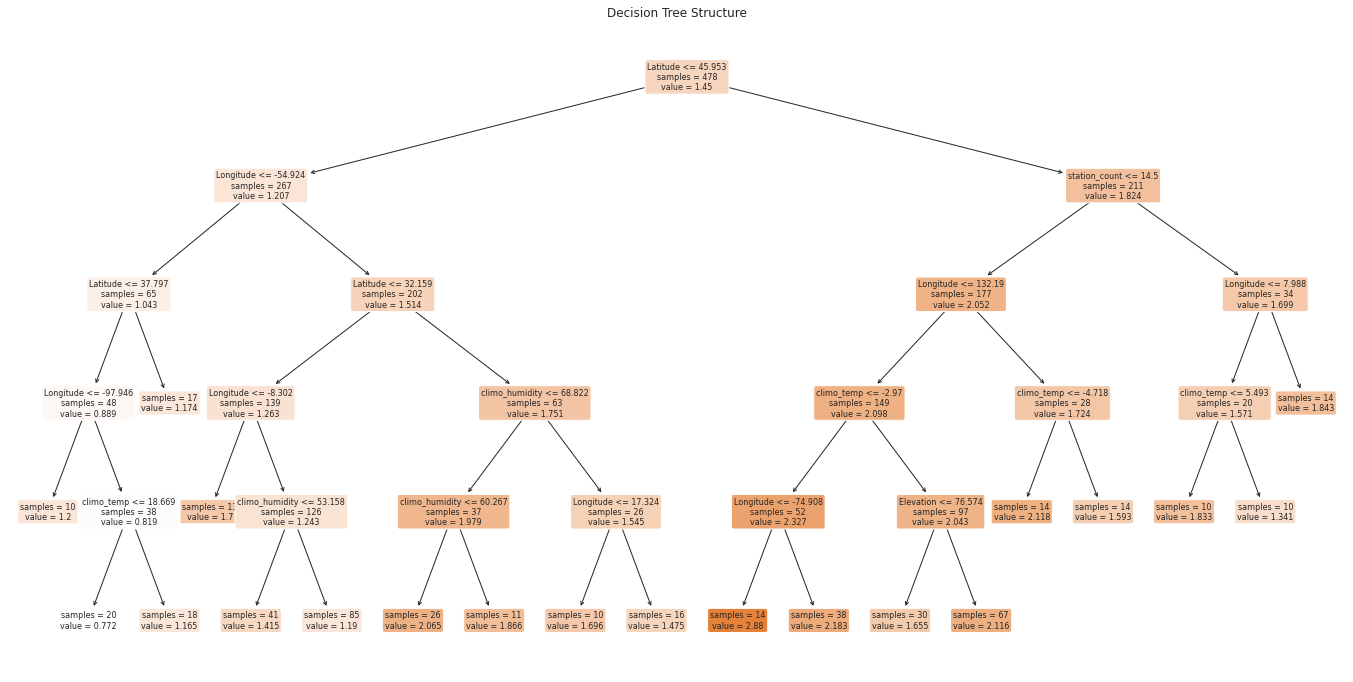

Saved decision tree plot to ../output/regridded_model_comparison/regridded_decision_tree_structure.png


In [7]:
from sklearn.tree import plot_tree

print(f"Decision tree depth: {tree_model.get_depth()}")
print(f"Decision tree leaves: {tree_model.get_n_leaves()}")

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=FEATURE_COLS,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
    ax=ax,
)
ax.set_title('Decision Tree Structure')


tree_plot_path = OUTPUT_DIR / 'regridded_decision_tree_structure.png'
fig.savefig(tree_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved decision tree plot to {tree_plot_path}")

In [8]:
metrics_df = pd.DataFrame([linear_metrics, tree_metrics])
metrics_path = OUTPUT_DIR / 'regridded_model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

comparison_cols = ['model', 'test_r2', 'test_rmse', 'test_mae', 'train_r2', 'train_rmse', 'train_mae']
print(metrics_df[comparison_cols].to_string(index=False))
print(f'')
print(f'Saved metrics to {metrics_path}')

metrics_df[comparison_cols]

                      model   test_r2  test_rmse  test_mae  train_r2  train_rmse  train_mae
 Weighted Linear Regression  0.428372   0.364130  0.264873  0.520599    0.337646   0.255266
    Decision Tree Regressor  0.480066   0.347275  0.257111  0.797031    0.219698   0.149214

Saved metrics to ../output/regridded_model_comparison/regridded_model_metrics.csv


,model,test_r2,test_rmse,test_mae,train_r2,train_rmse,train_mae
0,Weighted Linear Regression,0.428372,0.364130,0.264873,0.520599,0.337646,0.255266
1,Decision Tree Regressor,0.480066,0.347275,0.257111,0.797031,0.219698,0.149214


In [9]:
predictions_df = model_df[ID_COLS + FEATURE_COLS + [TARGET_COL, 'sample_weight']].copy()
predictions_df['linear_prediction'] = linear_model.predict(predictions_df[FEATURE_COLS])
predictions_df['tree_prediction'] = tree_model.predict(predictions_df[FEATURE_COLS])
predictions_df['linear_residual'] = predictions_df[TARGET_COL] - predictions_df['linear_prediction']
predictions_df['tree_residual'] = predictions_df[TARGET_COL] - predictions_df['tree_prediction']
predictions_df['split'] = np.where(predictions_df.index.isin(test_idx), 'test', 'train')

predictions_path = OUTPUT_DIR / 'regridded_model_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)
print(f'Saved per-cell predictions to {predictions_path}')

predictions_df.head()

Saved per-cell predictions to ../output/regridded_model_comparison/regridded_model_predictions.csv


,cell_id,lat_bin,lon_bin,lat_min,lat_max,lon_min,lon_max,climo_temp,climo_humidity,Latitude,Longitude,Elevation,station_count,slope,sample_weight,linear_prediction,tree_prediction,linear_residual,tree_residual,split
11,-55_-75,-55,-75,-55,-50,-75,-70,6.736994,75.225000,-53.000,-70.9670,37.0,1,-0.162984,1,0.901135,0.772000,-1.064119,-0.934984,train
12,-55_-70,-55,-70,-55,-50,-70,-65,6.989042,72.170833,-53.230,-68.7895,20.3,2,0.317727,2,0.915267,0.772000,-0.597540,-0.454273,train
16,-50_-70,-50,-70,-50,-45,-70,-65,13.159973,49.891667,-45.783,-67.5000,58.0,1,0.445777,1,0.968082,0.772000,-0.522305,-0.326223,test
19,-50_165,-50,165,-50,-45,165,170,10.020309,83.183333,-46.417,168.3330,2.0,1,1.044168,1,1.238011,1.189607,-0.193842,-0.145438,train
20,-50_170,-50,170,-50,-45,170,175,10.838073,78.000000,-45.900,170.5200,2.0,1,0.661559,1,1.259846,1.189607,-0.598286,-0.528047,train


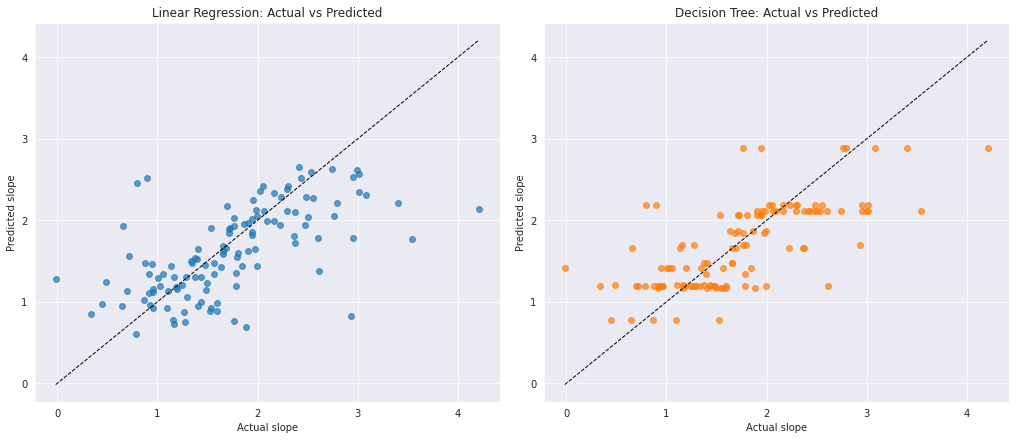

Saved scatter comparison to ../output/regridded_model_comparison/regridded_actual_vs_predicted.png


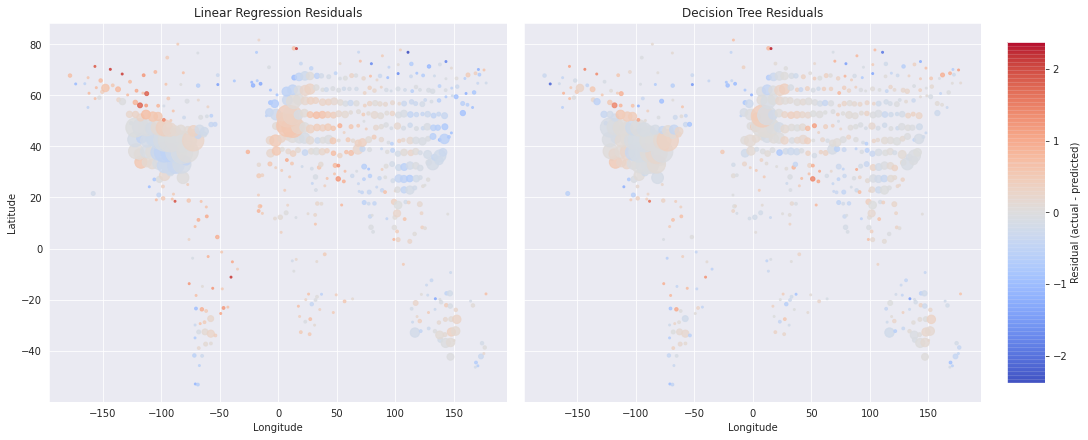

Saved residual maps to ../output/regridded_model_comparison/regridded_residual_maps.png


In [10]:
test_predictions = predictions_df[predictions_df['split'] == 'test'].copy()
diag_min = min(test_predictions[TARGET_COL].min(), test_predictions['linear_prediction'].min(), test_predictions['tree_prediction'].min())
diag_max = max(test_predictions[TARGET_COL].max(), test_predictions['linear_prediction'].max(), test_predictions['tree_prediction'].max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axes[0].scatter(test_predictions[TARGET_COL], test_predictions['linear_prediction'], alpha=0.7, s=35)
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], linestyle='--', color='black', linewidth=1)
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual slope')
axes[0].set_ylabel('Predicted slope')

axes[1].scatter(test_predictions[TARGET_COL], test_predictions['tree_prediction'], alpha=0.7, s=35, color='tab:orange')
axes[1].plot([diag_min, diag_max], [diag_min, diag_max], linestyle='--', color='black', linewidth=1)
axes[1].set_title('Decision Tree: Actual vs Predicted')
axes[1].set_xlabel('Actual slope')
axes[1].set_ylabel('Predicted slope')

scatter_path = OUTPUT_DIR / 'regridded_actual_vs_predicted.png'
fig.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved scatter comparison to {scatter_path}')

residual_limit = np.nanmax(np.abs([predictions_df['linear_residual'], predictions_df['tree_residual']]))
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True, constrained_layout=True)
linear_map = axes[0].scatter(
    predictions_df['Longitude'],
    predictions_df['Latitude'],
    c=predictions_df['linear_residual'],
    cmap='coolwarm',
    vmin=-residual_limit,
    vmax=residual_limit,
    s=predictions_df['station_count'] * 4,
    alpha=0.8
)
axes[0].set_title('Linear Regression Residuals')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

tree_map = axes[1].scatter(
    predictions_df['Longitude'],
    predictions_df['Latitude'],
    c=predictions_df['tree_residual'],
    cmap='coolwarm',
    vmin=-residual_limit,
    vmax=residual_limit,
    s=predictions_df['station_count'] * 4,
    alpha=0.8
)
axes[1].set_title('Decision Tree Residuals')
axes[1].set_xlabel('Longitude')

colorbar = fig.colorbar(tree_map, ax=axes.ravel().tolist(), shrink=0.9)
colorbar.set_label('Residual (actual - predicted)')

residual_path = OUTPUT_DIR / 'regridded_residual_maps.png'
fig.savefig(residual_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved residual maps to {residual_path}')

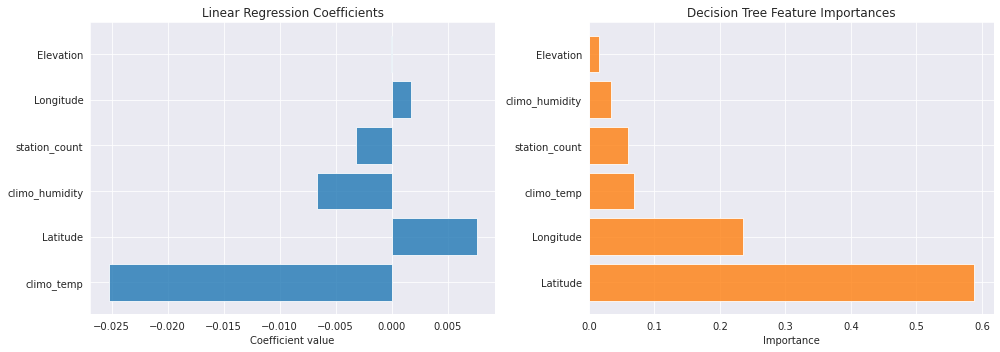

Saved feature summary to ../output/regridded_model_comparison/regridded_feature_summary.png
Summary:
- Best test R2: Decision Tree Regressor
- Test R2 spread across models: 0.0517
- Test RMSE difference (best - worst): -0.0169


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(linear_coefficients['feature'], linear_coefficients['coefficient'], color='tab:blue', alpha=0.8)
axes[0].set_title('Linear Regression Coefficients')
axes[0].set_xlabel('Coefficient value')

axes[1].barh(tree_importances['feature'], tree_importances['importance'], color='tab:orange', alpha=0.8)
axes[1].set_title('Decision Tree Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
feature_path = OUTPUT_DIR / 'regridded_feature_summary.png'
fig.savefig(feature_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved feature summary to {feature_path}')

best_model = metrics_df.loc[metrics_df['test_r2'].idxmax(), 'model']
r2_gain = metrics_df['test_r2'].max() - metrics_df['test_r2'].min()
rmse_gain = metrics_df['test_rmse'].min() - metrics_df['test_rmse'].max()
print('Summary:')
print(f'- Best test R2: {best_model}')
print(f'- Test R2 spread across models: {r2_gain:.4f}')
print(f'- Test RMSE difference (best - worst): {rmse_gain:.4f}')